#**السداسي المرح was here ;)**

#**Credits**
##**Absloute Cinema**



####**Marwan Ehab Adel (Markov)**

1. Getting the Data
2. Data Pre-Processing (Encoding)
3. Model Comparison
4. Finalizing, Structuring and Documenting

####**Youssef Ramadan Ahmed (El-gamal)**

1. Getting the Data
3. Data Pre-Processing
4. Full Numerical Model 😘

####**Mo'men Osama Galal (Mo')**

1. Getting the Data
2. EDA
4. Full Statistical Model 😘

####**Marwan Ahman Elsayed (El-Mahdi)**

1. Full Machine Learning Model 😘
2. Visualization

####**Nour "ElDeen" Ali (El-Kholy)**

1. Visualization 😘
2. Model Comparison

####**Marwan Mahammed (El-Maro)**

1. Visualization 😘
2. Documenting

#**Libraries Importing and Data Initializing**

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown

To get the public source of our data click [here](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

##**Dataset Description**

>The dataset contains **2938 records** for **192 countries** over the interval **2000–2015**.

>Each record represents a country in a specific year.

>Countries are classified as Developed or Developing, with the majority belonging to the developing group.

>The target variable is life expectancy which ranges **from 36.3 to 89 years** with **mean = 69.2** years and showing clear variation across countries.

>Overall, the dataset shows massive variation across *health*, *economic* and *social* factors with **Missing values**, **Duplicates**, **Strip-needed column's names**, **Categorical columns** and **redundant irrelevant columns**.

---
##**Column Description**


>**Country**  
Name of the country where the observations were recorded.

>**Year**  
Year of observation, ranging from 2000 to 2015.

>**Status**  
Development status of the country (Developed or Developing).

>**Life expectancy**  
Average life expectancy at birth (in years). This is the target variable.

>**Adult Mortality**  
Adult mortality rate representing the probability of dying between ages 15 and 60 per 1000 population.

>**infant deaths**  
Number of infant deaths per 1000 population.

>**Alcohol**  
Per‑capita alcohol consumption (liters of pure alcohol) for individuals aged 15 and above.

>**percentage expenditure**  
Health expenditure as a percentage of Gross Domestic Product (GDP) per capita.

>**Hepatitis B**  
Percentage of one‑year‑old children immunized against Hepatitis B.

>**Measles**  
Number of reported measles cases per 1000 population.

>**BMI**  
Average Body Mass Index of the population.

>**under‑five deaths**  
Number of deaths among children under five years of age per 1000 population.

>**Polio**  
Percentage of one‑year‑old children immunized against Polio.

>**Total expenditure**  
Government expenditure on health as a percentage of total government spending.

>**Diphtheria**  
Percentage of one‑year‑old children immunized against Diphtheria (DTP3).

>**HIV/AIDS**  
Deaths due to HIV/AIDS per 1000 live births among children aged 0–4.

>**GDP**  
Gross Domestic Product per capita in US dollars.

>**Population**  
Total population of the country in that year.

>**thinness 1‑19 years**  
Percentage of children and adolescents aged 10–19 who are thin or underweight.

>**thinness 5‑9 years**  
Percentage of children aged 5–9 who are thin or underweight.

>**Income composition of resources**  
Human Development Index component measuring income (scaled between 0 and 1).

>**Schooling**  
Average number of years of schooling received by the population.


In [178]:
import kagglehub

path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
df = pd.read_csv(path + "/Life Expectancy Data.csv")

Using Colab cache for faster access to the 'life-expectancy-who' dataset.


# **Pre-Processing**

#### **Let's do some EDA**

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [180]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


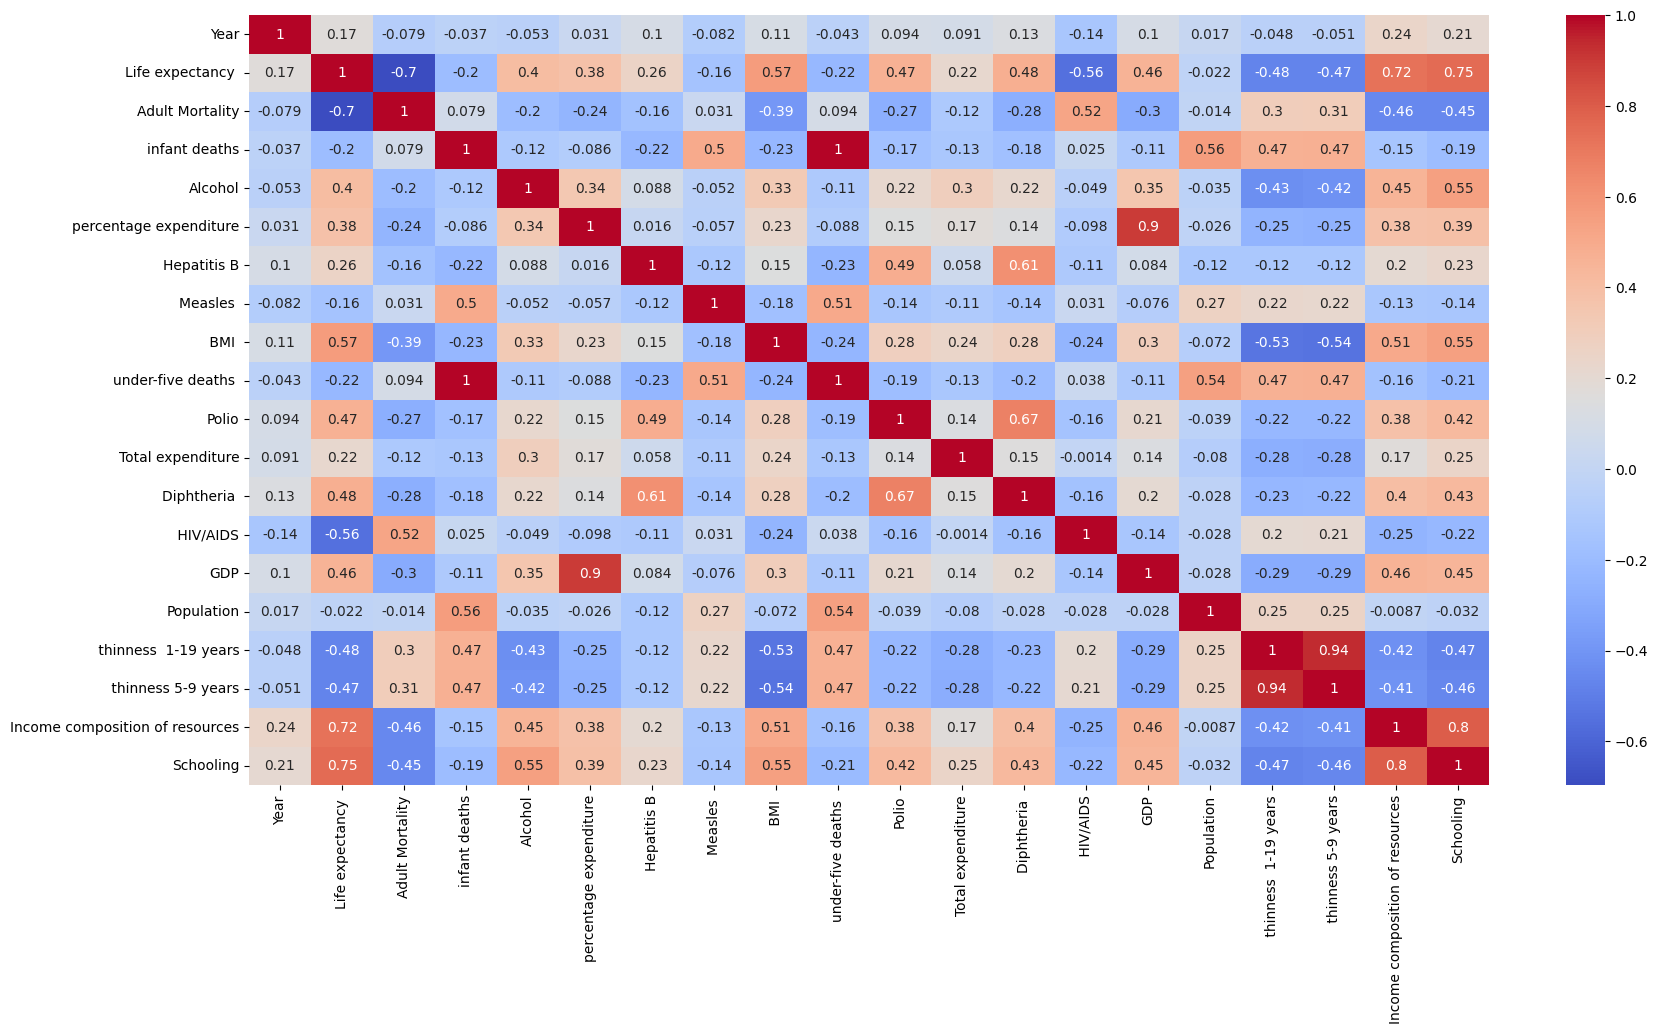

In [181]:
plt.figure(figsize=(20, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

####**Column's names and Duplicates**

In [182]:
df.columns = df.columns.str.strip() # the column's names contain some extra spaces so we removed it

In [183]:
df.drop_duplicates(inplace=True)

####**Droping the irrelevant columns (with low corr. nearly equal to 0)**

In [184]:
df.drop(columns=["thinness  1-19 years", "thinness 5-9 years", "Population", "Total expenditure", "under-five deaths", "Measles", "Hepatitis B", "infant deaths", "Year"], inplace=True)

####**Dealing with NA values**

In [185]:
df['Adult Mortality'] = df['Adult Mortality'].fillna(df['Adult Mortality'].median())
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['Polio'] = df['Polio'].fillna(df['Polio'].median())
df['Diphtheria'] = df['Diphtheria'].fillna(df['Diphtheria'].median())
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
df['Income composition of resources'] = df['Income composition of resources'].fillna(df['Income composition of resources'].median())
df['Schooling'] = df['Schooling'].fillna(df['Schooling'].median())

In [186]:
df.dropna(subset=['Life expectancy'], inplace=True)

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2928 non-null   object 
 1   Status                           2928 non-null   object 
 2   Life expectancy                  2928 non-null   float64
 3   Adult Mortality                  2928 non-null   float64
 4   Alcohol                          2928 non-null   float64
 5   percentage expenditure           2928 non-null   float64
 6   BMI                              2928 non-null   float64
 7   Polio                            2928 non-null   float64
 8   Diphtheria                       2928 non-null   float64
 9   HIV/AIDS                         2928 non-null   float64
 10  GDP                              2928 non-null   float64
 11  Income composition of resources  2928 non-null   float64
 12  Schooling                

####**Final Pre-Processing Visuals (Corr. heat map & Target Distr.)**

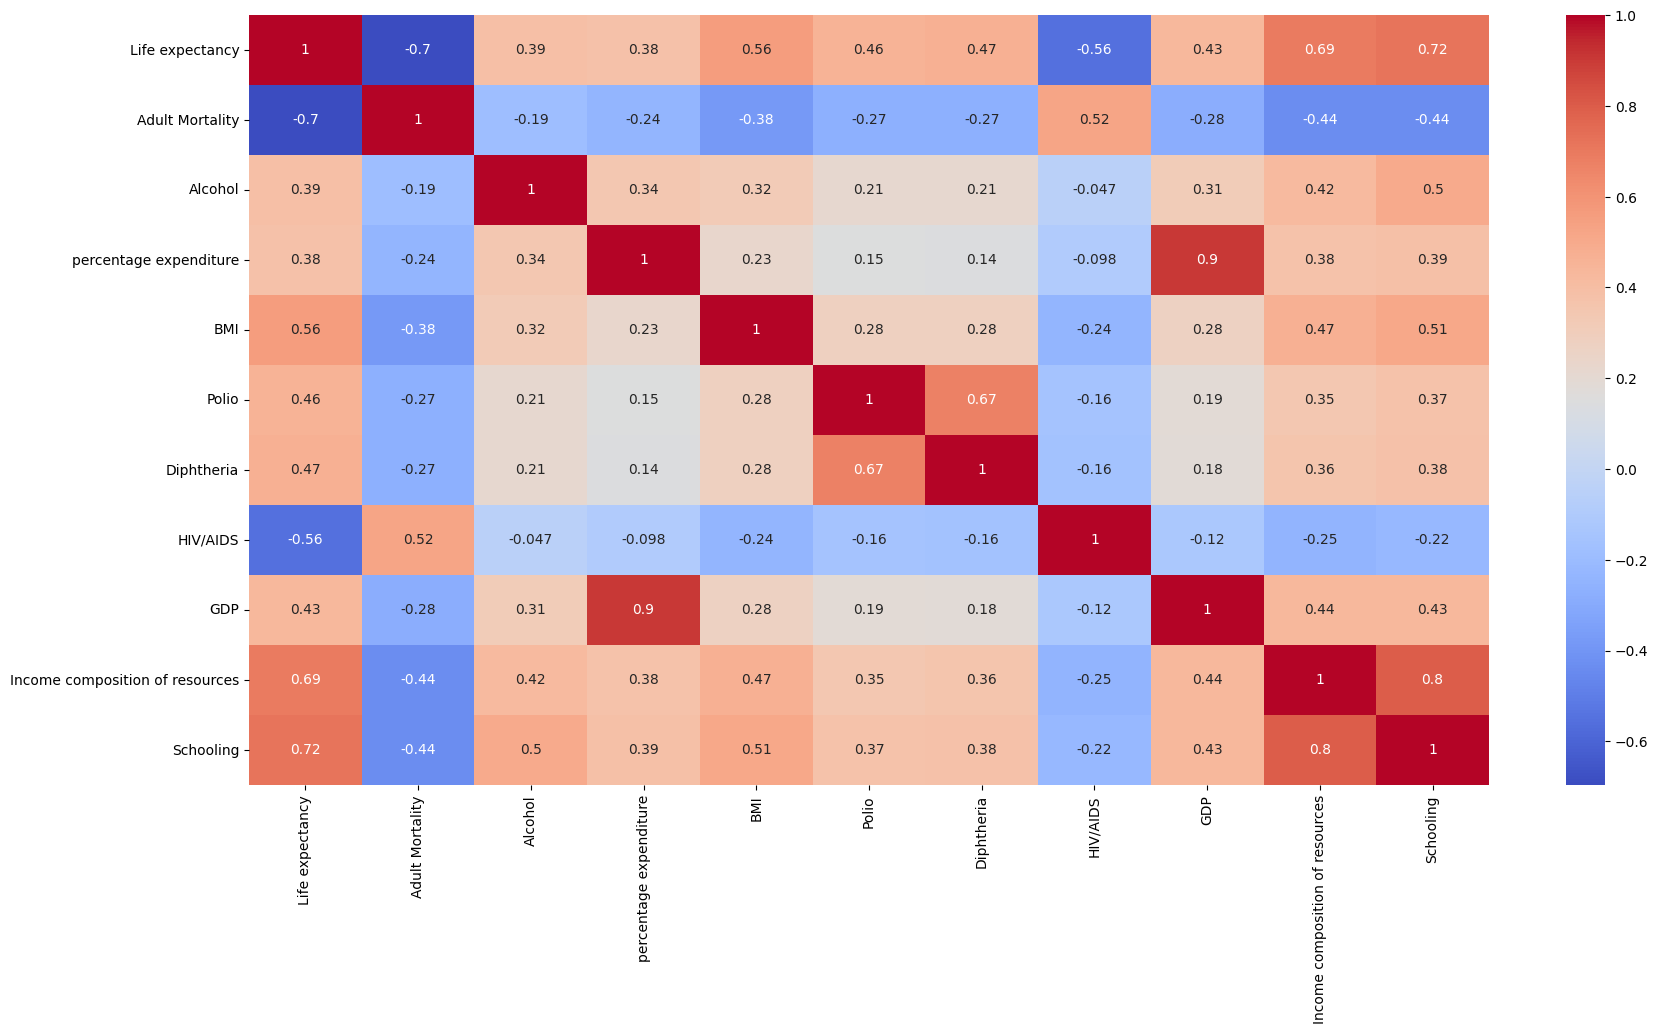

In [188]:
plt.figure(figsize=(20, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

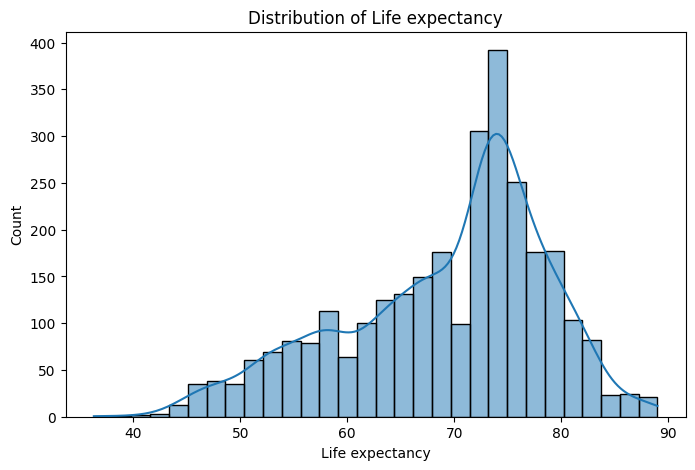

In [189]:
plt.figure(figsize=(8,5))
sns.histplot(df['Life expectancy'], bins=30, kde=True)
plt.title("Distribution of Life expectancy")
plt.show()

#**Models [ Numerical, Machine Learning, Statistical ]**

## **Numerical Model**

#### Simple Linear Regression Model Using Numerical View

In [190]:
class SimpleLinearResgressionNumericalView:
    def __init__(self):
        self.B0 = None
        self.B1 = None
        self.SSE = None
        self.MSE = None
        self.r2 = None

        self.lambda_l2 = 0.0 #Ridge
        self.lambda_l1 = 0.0 #Lasso

    def predict(self, X):
        X = np.asarray(X, dtype=float).reshape(-1)
        return self.B0 + self.B1 * X

    @staticmethod
    def sse(y, y_hat):
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, lambda_l2 = 0.0, lambda_l1 = 0.0, show_steps=True):
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)

        n = len(X)

        Sx = np.sum(X)
        Sy = np.sum(y)
        Sxx = np.sum(X ** 2)
        Sxy = np.sum(X * y)

        if show_steps:
            print("Step 1: Define SSE")
            print("SSE = Σ(yi - B0 - B1 xi)^2\n")
            print("Step 2: Compute Summations")
            print(f"n = {n}")
            print(f"Σxi = {Sx}")
            print(f"Σyi = {Sy}")
            print(f"Σxi^2 = {Sxx}")
            print(f"Σxiyi = {Sxy}\n")
            print("Step 3: Two Normal Equations")
            print(f"Σyi = n B0 + B1 Σxi")
            print(f"{Sy} = {n} B0 + {Sx} B1")
            print()
            print(f"Σxiyi = B0 Σxi + B1 Σxi^2")
            print(f"{Sxy} = {Sx} B0 + {Sxx} B1\n")
            print("Step 4: Matrix Form")
            print("[[ n Σxi ]] [B0] = [ Σyi ]")
            print("[[ Σxi Σxi^2]] [B1] [ Σxiyi ]\n")

        A = np.array([
            [n, Sx],
            [Sx, Sxx + (n * lambda_l2) ]], dtype=float) # Adding Ridge

        def sign(x):
            if x > 0:
                return 1
            elif x < 0:
                return -1
            else:
                return 0


        b = np.array([Sy, Sxy], dtype=float)

        self.B0, self.B1 = np.linalg.solve(A, b)

        if(lambda_l1 != 0.0):
            print(f"Sign of B1 => {sign(self.B1)}")
            b = np.array([Sy, Sxy - (sign(self.B1) * n * lambda_l1) ], dtype=float) # Adding Lasso
            self.B0, self.B1 = np.linalg.solve(A, b)


        if show_steps:
            print("Step 5: Solve the System")
            print(f"B0 = {self.B0}")
            print(f"B1 = {self.B1}\n")

        y_hat = self.predict(X)
        self.SSE = self.sse(y, y_hat)
        self.MSE = self.SSE / n

        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        self.r2 = 1 - (ss_res / ss_tot)


        if show_steps:
            print("Final Model:")

            print(f"ŷ = {self.B0:.4f} + {self.B1:.4f} x\n")
            print(f"SSE = {self.SSE}")
            print(f"MSE = {self.MSE}")
            print(f"R2 = {self.r2}")

        return self

## **Machine Learning Model**

#### Multiple Linear Regression Model Using Machine Learning View

In [191]:
class MultipleLinearRegressionGD:

    def __init__(self):
        # Model Parameters
        self.B_0 = None     # Intercept
        self.B = None       # Coefficients (for multiple features)

        # Evaluation metrics
        self.SSE = float('inf')
        self.MSE = None
        self.RMSE = None

        # Regularization Parameters
        self.lambda_l1 = 0.0    # Lasso
        self.lambda_l2 = 0.0    # Ridge

        # List to save the loss for each iteration
        self.loss_list = []
        self.betas = []


    def fit(self, X, y, learning_rate = 0.01, epochs = 1000,
            lambda_l1 = 0.0, lambda_l2 = 0.0, tolerance = 1e-1):

        # Convert to numpy arrays
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        n, features = X.shape

        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2

        # Initialize Parameters
        self.B_0 = 0.0
        self.B = np.zeros(features)

        prev_SSE = float('inf')

        for _ in range(epochs):

            # Step 1 : Prediction
            y_hat = self.B_0 + np.dot(X, self.B)

            # Step 2 : Error
            error = y_hat - y

            # Step 3 : Gradients

            # Intercept Gradient
            dB_0 = ( 1 / n ) * np.sum(error)

            # Ridge Term (L2)
            ridge_term =  (self.lambda_l2 / n) * self.B

            # Lasso Term (L1)
            lasso_term =  (self.lambda_l1 / (2 * n) ) * np.sign(self.B)

            # Coefficient Gradient
            dB = ( 1 / n ) * np.dot(X.T, error) + ridge_term + lasso_term

            # Step 4 : Update
            self.B_0 -= learning_rate * dB_0
            self.B -= learning_rate * dB

            # Step 5 : Check Convergence
            new_SSE  = np.sum((self.predict(X) - y) ** 2)

            # Step 6 : Save new_SSE inside loss_list
            self.loss_list.append(new_SSE)

            if abs(prev_SSE - new_SSE) < tolerance :
                self.SSE = new_SSE
                self.betas = self.B.tolist()
                self.betas.append(self.B_0)
                break

            prev_SSE = new_SSE
            self.betas = self.B.tolist()
            self.betas.append(self.B_0)

        # Final Metrics
        self.SSE = new_SSE
        self.MSE = self.SSE / (n * 2)
        self.RMSE = np.sqrt(self.MSE)
        print(f"SSE : {self.SSE}")
        print(f"MSE : {self.MSE}")
        print(f"RMSE : {self.RMSE}")

    def predict(self, X):
        X = np.array(X, dtype= float)
        return self.B_0 + np.dot(X, self.B)

## **Statistical Model**

#### Simple Linear Regression Model Using Statistical View

In [192]:
class SimpleLinearRegressionStatisticalView:
    def __init__(self):
        self.B_0 = None
        self.B_1 = None

        # Error metrics
        self.MSE = None

        # Regularization parameters
        self.Lamda_1 = 0 # Lasso parameter
        self.Lamda_2 = 0 # Ridge parameter

    def fit(self, X, y, Lamda_1=0, Lamda_2=0):
        X = np.array(X)
        y = np.array(y)

        self.Lamda_1 = Lamda_1
        self.Lamda_2 = Lamda_2

        x_bar = X.mean()
        y_bar = y.mean()

        Sxx = np.sum(X**2) - len(X) * (x_bar**2)
        Sxy = np.sum(X * y) - len(X) * x_bar * y_bar

        if self.Lamda_2 > 0:
            self.B_1 = Sxy / (Sxx + len(X) * self.Lamda_2)

        elif self.Lamda_1 > 0:
            penalty = self.Lamda_1 / 2
            if Sxy > penalty:
                self.B_1 = (Sxy - penalty) / Sxx
            elif Sxy < -penalty:
                self.B_1 = (Sxy + penalty) / Sxx
            else:
                self.B_1 = 0.0

        else:
            self.B_1 = Sxy / Sxx

        self.B_0 = y_bar - self.B_1 * x_bar

        y_hat = self.predict(X)
        sse = np.sum((y - y_hat)**2)
        self.MSE = sse / (len(X) - 2)

    def predict(self, X):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet. Please call fit() first.")
        X = np.array(X)
        return self.B_0 + self.B_1 * X

# **Model Comparison**

#### **1st Case:** Encoding the categorical columns {Country, Status} using target mean encoding to test the corr. between the whole data columns and see what is the best column/feature to apply it in the simple models.

In [193]:
test = df.copy()
mean = df.groupby('Country')['Life expectancy'].mean()
test['country_mean'] = test['Country'].map(mean)

mean = df.groupby('Status')['Life expectancy'].mean()
test['Status_mean'] = test['Status'].map(mean)
test.dropna()

,Country,Status,Life expectancy,Adult Mortality,Alcohol,percentage expenditure,BMI,Polio,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling,country_mean,Status_mean
0,Afghanistan,Developing,65.0,263.0,0.01,71.279624,19.1,6.0,65.0,0.1,584.259210,0.479,10.1,58.19375,67.111465
1,Afghanistan,Developing,59.9,271.0,0.01,73.523582,18.6,58.0,62.0,0.1,612.696514,0.476,10.0,58.19375,67.111465
2,Afghanistan,Developing,59.9,268.0,0.01,73.219243,18.1,62.0,64.0,0.1,631.744976,0.470,9.9,58.19375,67.111465
3,Afghanistan,Developing,59.5,272.0,0.01,78.184215,17.6,67.0,67.0,0.1,669.959000,0.463,9.8,58.19375,67.111465
4,Afghanistan,Developing,59.2,275.0,0.01,7.097109,17.2,68.0,68.0,0.1,63.537231,0.454,9.5,58.19375,67.111465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,Developing,44.3,723.0,4.36,0.000000,27.1,67.0,65.0,33.6,454.366654,0.407,9.2,50.48750,67.111465
2934,Zimbabwe,Developing,44.5,715.0,4.06,0.000000,26.7,7.0,68.0,36.7,453.351155,0.418,9.5,50.48750,67.111465
2935,Zimbabwe,Developing,44.8,73.0,4.43,0.000000,26.3,73.0,71.0,39.8,57.348340,0.427,10.0,50.48750,67.111465
2936,Zimbabwe,Developing,45.3,686.0,1.72,0.000000,25.9,76.0,75.0,42.1,548.587312,0.427,9.8,50.48750,67.111465


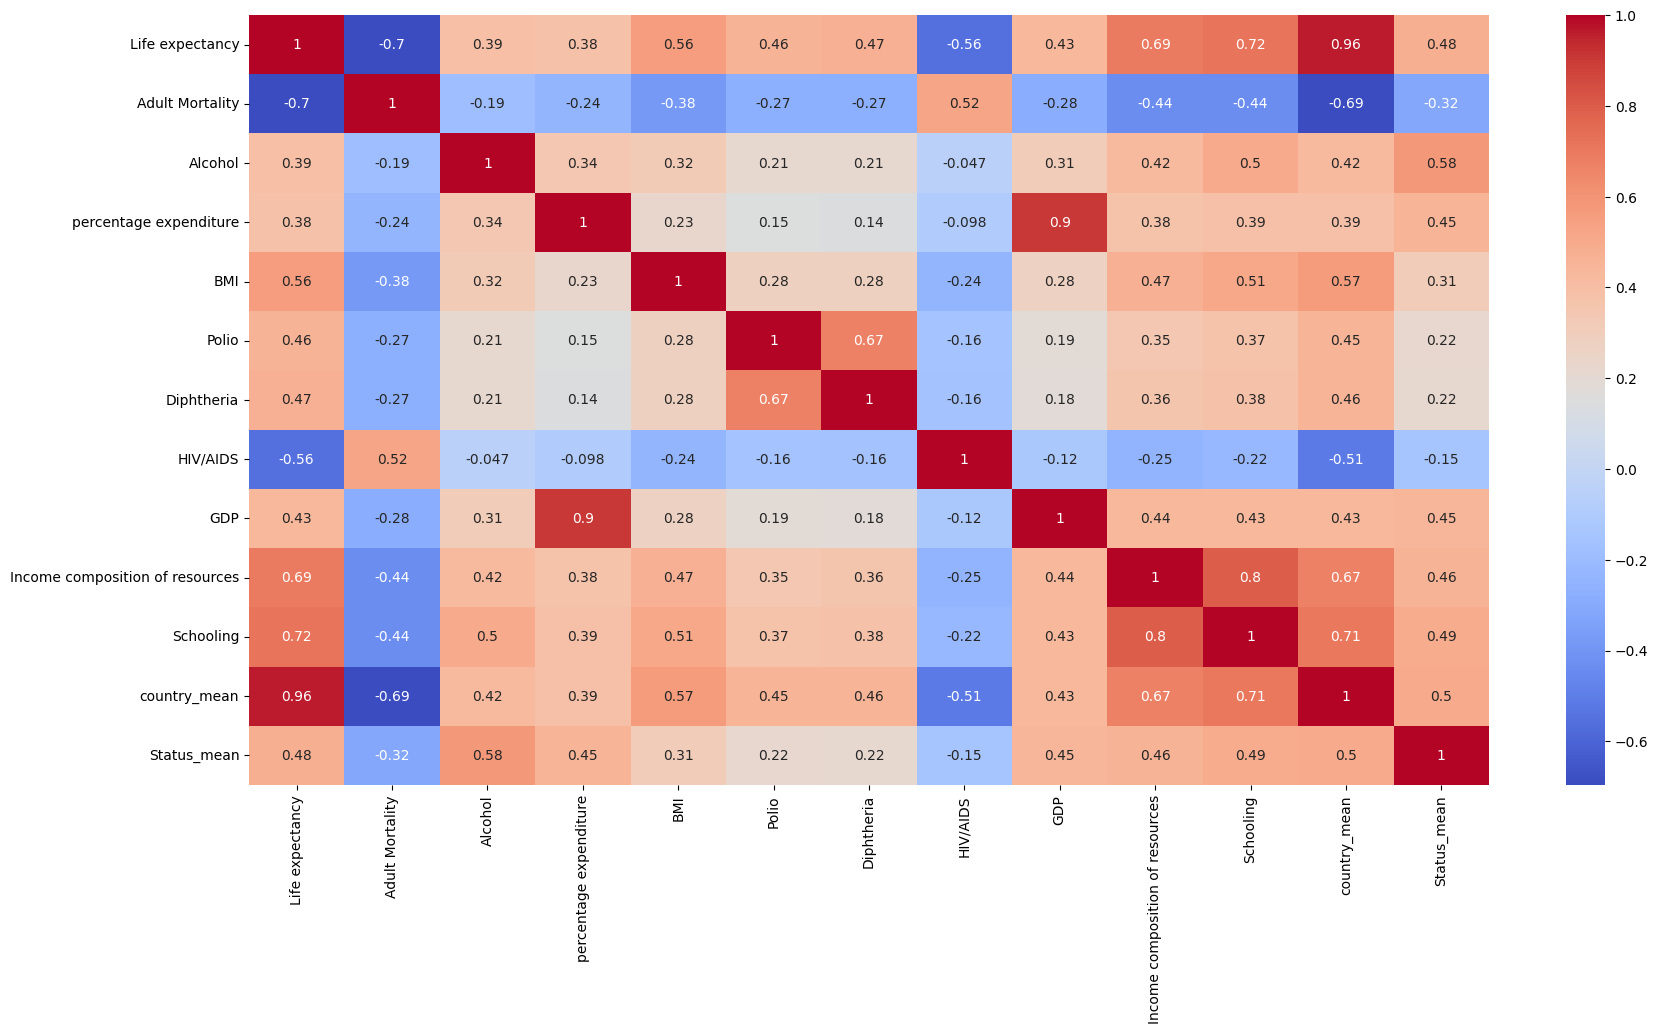

In [194]:
plt.figure(figsize=(20, 10))
corr = test.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

We notice that the **country** is the highest corr. of all columns with value equal to **0.96**

In [195]:
corr['Life expectancy'].sort_values(ascending=False)

,Life expectancy
Life expectancy,1.000000
country_mean,0.962095
Schooling,0.717314
Income composition of resources,0.688591
BMI,0.558778
Status_mean,0.482136
Diphtheria,0.473268
Polio,0.459458
GDP,0.430992
Alcohol,0.390633


Now we will encode the country column with target mean value of each country but with smoothing and we will split the data into train and test to prevent and test the column leackage

In [196]:
X_train, X_test, y_train, y_test = train_test_split(df['Country'], df['Life expectancy'], test_size=0.2, random_state=41)
df_train = pd.DataFrame({'Country': X_train, 'Life expectancy': y_train})
df_test = pd.DataFrame({'Country': X_test, 'Life expectancy': y_test})

# Calculate global mean and global count from training data
global_mean = df_train['Life expectancy'].mean()
global_count = len(df_train)

# Calculate country-specific counts and means from training data
country_stats = df_train.groupby('Country')['Life expectancy'].agg(
    country_count='count',
    country_mean='mean'
)

# Apply the smoothing formula to create the target mapping (Series)
# Using global_count as a smoothing factor 'k'
smoothing_factor_k = global_count

smoothed_country_map = (
    country_stats['country_count'] * country_stats['country_mean'] + smoothing_factor_k * global_mean
) / (country_stats['country_count'] + smoothing_factor_k)

# Map the 'Country' column in df_train using the smoothed values
df_train['Country'] = df_train['Country'].map(smoothed_country_map)

# Map the 'Country' column in df_test.
# For countries in df_test that were not in df_train, map will return NaN.
# Fill these NaNs with the global mean from the training data.
df_test['Country'] = df_test['Country'].map(smoothed_country_map).fillna(global_mean)

df_train.dropna(subset=['Life expectancy'], inplace=True)
df_test.dropna(subset=['Life expectancy'], inplace=True)

In [197]:
x = df_train['Country']
y = df_train['Life expectancy']

In [198]:
n = SimpleLinearResgressionNumericalView()
n.fit(x, y)

Step 1: Define SSE
SSE = Σ(yi - B0 - B1 xi)^2

Step 2: Compute Summations
n = 2342
Σxi = 162202.99124106485
Σyi = 162203.19999999998
Σxi^2 = 11233913.243363488
Σxiyi = 11235020.520927776

Step 3: Two Normal Equations
Σyi = n B0 + B1 Σxi
162203.19999999998 = 2342 B0 + 162202.99124106485 B1

Σxiyi = B0 Σxi + B1 Σxi^2
11235020.520927776 = 162202.99124106485 B0 + 11233913.243363488 B1

Step 4: Matrix Form
[[ n Σxi ]] [B0] = [ Σyi ]
[[ Σxi Σxi^2]] [B1] [ Σxiyi ]

Step 5: Solve the System
B0 = -12268.379273914768
B1 = 178.13942417723501

Final Model:
ŷ = -12268.3793 + 178.1394 x

SSE = 17398.585204117542
MSE = 7.428943298086056
R2 = 0.9183823202201313


In [199]:
residuals = y - n.predict(x)

fig4 = px.scatter(
    x=n.predict(x), y=residuals,
    labels={'x': 'Predicted (y_hat)', 'y': 'Residuals (e)'},
    title=" Residual Plot for Model Specification"
)
fig4.add_hline(y=residuals.mean(), line_dash="dash", line_color="black")
fig4.show()

Trying our test data and test our leackage and there is no overfitting الحمدلله

In [200]:
test = pd.DataFrame({"Prediction":n.predict(df_test['Country']),'Real Value':df_test['Life expectancy']})
r2 = r2_score(test['Real Value'], test['Prediction'])
print(f"R2: {r2}")

R2: 0.8912367605490992


Using the different approaches { OLS, Lasso, Ridge } on **numerical** view model

In [201]:
n.fit(x, y)
print(30*"_")
print(f"OLS: B1={n.B1:.3f}, B0={n.B0:.3f}, MSE={n.MSE:.3f}")
print(30*"_")
n.fit(x, y, lambda_l1=15)
print(f"Lasso: B1={n.B1:.3f}, B0={n.B0:.3f}, MSE={n.MSE:.3f}")
print(30*"_")
n.fit(x, y, lambda_l2=15)
print(f"Ridge: B1={n.B1:.3f}, B0={n.B0:.3f}, MSE={n.MSE:.3f}")
print(30*"_")

Step 1: Define SSE
SSE = Σ(yi - B0 - B1 xi)^2

Step 2: Compute Summations
n = 2342
Σxi = 162202.99124106485
Σyi = 162203.19999999998
Σxi^2 = 11233913.243363488
Σxiyi = 11235020.520927776

Step 3: Two Normal Equations
Σyi = n B0 + B1 Σxi
162203.19999999998 = 2342 B0 + 162202.99124106485 B1

Σxiyi = B0 Σxi + B1 Σxi^2
11235020.520927776 = 162202.99124106485 B0 + 11233913.243363488 B1

Step 4: Matrix Form
[[ n Σxi ]] [B0] = [ Σyi ]
[[ Σxi Σxi^2]] [B1] [ Σxiyi ]

Step 5: Solve the System
B0 = -12268.379273914768
B1 = 178.13942417723501

Final Model:
ŷ = -12268.3793 + 178.1394 x

SSE = 17398.585204117542
MSE = 7.428943298086056
R2 = 0.9183823202201313
______________________________
OLS: B1=178.139, B0=-12268.379, MSE=7.429
______________________________
Step 1: Define SSE
SSE = Σ(yi - B0 - B1 xi)^2

Step 2: Compute Summations
n = 2342
Σxi = 162202.99124106485
Σyi = 162203.19999999998
Σxi^2 = 11233913.243363488
Σxiyi = 11235020.520927776

Step 3: Two Normal Equations
Σyi = n B0 + B1 Σxi
16220

Using the different approaches { OLS, Lasso, Ridge } on **Statistical** view model

In [202]:
model = SimpleLinearRegressionStatisticalView()

model.fit(x, y)
print(f"OLS: B1={model.B_1:.3f}, B0={model.B_0:.3f}, MSE={model.MSE:.3f}")

model.fit(x, y, Lamda_1=15)
print(f"Lasso: B1={model.B_1:.3f}, B0={model.B_0:.3f}, MSE={model.MSE:.3f}")

model.fit(x, y, Lamda_2=15)
print(f"Ridge: B1={model.B_1:.3f}, B0={model.B_0:.3f}, MSE={model.MSE:.3f}")

OLS: B1=178.139, B0=-12268.379, MSE=7.435
Lasso: B1=176.924, B0=-12184.182, MSE=7.439
Ridge: B1=0.031, B0=67.092, MSE=91.070


In [203]:
residuals = y - model.predict(x)

fig4 = px.scatter(
    x=model.predict(x), y=residuals,
    labels={'x': 'Predicted (y_hat)', 'y': 'Residuals (e)'},
    title=" Residual Plot for Model Specification"
)
fig4.add_hline(y=residuals.mean(), line_dash="dash", line_color="black")
fig4.show()

Encoding the categorical features using **One Hot Encoding** to use it in the **Machine Learning** view model

In [204]:
df_encoded = pd.concat([pd.get_dummies(df[['Status','Country']],dtype=int), df.drop(columns=['Country', 'Status'])], axis=1)

####**2nd Case:** Fitting the model on the whole data features

Transforming the data using z-score method

In [205]:
z = StandardScaler()

features = df_encoded.drop(columns=['Life expectancy'])
df_scaled = z.fit_transform(features)
df_train = pd.DataFrame(df_scaled, columns=features.columns)

In [206]:
model = MultipleLinearRegressionGD()
model.fit(df_train, df['Life expectancy'], learning_rate=0.001,epochs=10000)

SSE : 12720.243681629918
MSE : 2.1721727598411746
RMSE : 1.47382928449708


####**3nd Case:** Fitting the model on the domain knowledge selected data features

Transforming the data using z-score method

In [207]:
features = df_encoded.drop(columns=['Life expectancy', 'Diphtheria', 'Polio', 'GDP', 'Alcohol', 'percentage expenditure', 'HIV/AIDS'])
df_scaled = z.fit_transform(features)
df_train = pd.DataFrame(df_scaled, columns=features.columns)

In [208]:
Linearmodel = MultipleLinearRegressionGD()
Linearmodel.fit(df_train, df['Life expectancy'], learning_rate=0.001,epochs=10000)

SSE : 16473.140616850123
MSE : 2.8130363075222204
RMSE : 1.6772108715132454


#####**ML Lasso case model**

In [209]:
Lassomodel = MultipleLinearRegressionGD()
Lassomodel.fit(df_train, df['Life expectancy'], learning_rate=0.001,epochs=int(1e4), lambda_l1=20)

SSE : 16528.146032324923
MSE : 2.8224293087986547
RMSE : 1.6800087228340972


In [210]:
residuals = df['Life expectancy'] - Lassomodel.predict(df_train)

fig = px.scatter(
    x=Lassomodel.predict(df_train), y=residuals,
    labels={'x': 'Predicted (y_hat)', 'y': 'Residuals (e)'},
    title=" Residual Plot for Model Specification"
)
fig.add_hline(y=residuals.mean(), line_dash="dash", line_color="black")
fig.show()

#####**ML Ridge case model**

In [211]:
Ridgemodel = MultipleLinearRegressionGD()
Ridgemodel.fit(df_train, df['Life expectancy'], learning_rate=0.001,epochs=int(1e4), lambda_l2=20)

SSE : 16523.288709088927
MSE : 2.8215998478635465
RMSE : 1.6797618426025596


In [212]:
residuals = df['Life expectancy'] - Ridgemodel.predict(df_train)

fig = px.scatter(
    x=Ridgemodel.predict(df_train), y=residuals,
    labels={'x': 'Predicted (y_hat)', 'y': 'Residuals (e)'},
    title=" Residual Plot for Model Specification"
)
fig.add_hline(y=residuals.mean(), line_dash="dash", line_color="black")
fig.show()

#**Visualization**

In [213]:
px.scatter(x=range(len(model.loss_list)), y=model.loss_list)

In [214]:

# Keep only numeric columns and drop rows with missing values for stable fitting
numeric_df = df.select_dtypes(include=[np.number]).copy()
target_col = "Life expectancy"

# Candidate X features
x_features = [c for c in numeric_df.columns if c != target_col]

def plot_feature_vs_target(feature):
    # Prepare clean data for selected feature + target
    temp = numeric_df[[feature, target_col]].dropna()
    x = temp[feature].values
    y = temp[target_col].values

    # Linear fit (same formula style as your notebook)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    y_pred = intercept + slope * x

    # Sort for smooth regression line
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_pred_sorted = y_pred[idx]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode="markers",
        name="Data",
        marker=dict(size=6, color="royalblue", opacity=0.7)
    ))

    fig.add_trace(go.Scatter(
        x=x_sorted, y=y_pred_sorted,
        mode="lines",
        name="Regression Line",
        line=dict(color="crimson", width=3)
    ))

    fig.update_layout(
        title=f"{feature} vs {target_col}",
        xaxis_title=feature,
        yaxis_title=target_col,
        template="plotly_white"
    )

    fig.show()

interact(
    plot_feature_vs_target,
    feature=Dropdown(options=x_features, value=x_features[0], description="Feature:")
)

interactive(children=(Dropdown(description='Feature:', options=('Adult Mortality', 'Alcohol', 'percentage expe…

<function __main__.plot_feature_vs_target(feature)>

In [215]:
fig = go.Figure(data=[
    go.Bar(name='Normal Linear Regression', x=[f'B_{i}' for i in range (1,len(Linearmodel.betas))].append('B_0'),y=Linearmodel.betas),
    go.Bar(name='Lasso Linear Regression', x=[f'B_{i}' for i in range (1,len(Lassomodel.betas))].append('B_0'),y=Lassomodel.betas),
    go.Bar(name='Ridge Linear Regression', x=[f'B_{i}' for i in range (1,len(Ridgemodel.betas))].append('B_0'),y=Ridgemodel.betas)
])
fig.update_layout(barmode='group')
fig.show()